In [5]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
sns.set(style="whitegrid")
sns.set_context("paper", font_scale=0.5)
plt.rcParams["font.family"] = "serif"
notebook_dir = Path().resolve()
parent_dir = notebook_dir.parent

data_dir = parent_dir / "data"
figures_dir = parent_dir / "figures"

if not figures_dir.exists():
    figures_dir.mkdir()

In [6]:
df = pd.read_csv(os.path.join(data_dir,"evalScores0.6.csv"))
df.head()

,sample_id,model_name,programming_language,length_bucket,bt_language,reference_summary,generated_summary,backtranslated_summary,bertscore_precision,bertscore_recall,bertscore_f1,bleu,chrf++,rougeL,meteor,comet,side,prompt_used,code,docstring
0,sample_68262,codegemma-7b-it,go,short,chinese,## Code Summary:\n\n**Function:** Use\n\n**Pur...,**函数名称：** Use\n\n**函数用途：** 将给定的路由处理器添加到 Handle...,**Function Name:** Use\n\n**Function Purpose:*...,0.9173,0.9130,0.9151,0.328843,0.479059,0.377358,0.525757,0.793025,0.951876,0,func (hs *HandlersStack) Use(h RouterHandler) ...,// Use adds a handler to the handlers stack.
1,sample_59144,codegemma-7b-it,go,short,chinese,## Function Summary: Config()\n\n**Purpose:** ...,## 代码摘要\n\n**函数名:** Config\n\n**函数用途:** 获取节点配置...,## Code Summary\n\n**Function Name:** Config\n...,0.9310,0.9239,0.9274,0.365100,0.524844,0.426540,0.463868,0.855142,0.783150,0,"func (n *NodeTx) Config() (map[string]string, ...",// Config fetches all LXD node-level config keys.
2,sample_56854,codegemma-7b-it,go,short,chinese,**Function Name:** LogField\n\n**Purpose:** Th...,## 代码摘要\n\n**函数名:** LogField\n\n**函数用途:** 将键值对...,## Code Summary\n\n**Function Name:** LogField...,0.8747,0.8992,0.8868,0.142393,0.376426,0.315789,0.370370,0.770519,0.803816,0,"func (d *DefaultContext) LogField(key string, ...",// LogField adds the key/value pair onto the L...
3,sample_63319,codegemma-7b-it,go,short,chinese,**Function:** UnmarshalJSON\n\n**Purpose:** To...,**函数名称:** UnmarshalJSON\n\n**函数用途:** 解码 JSON 数...,**Function Name:** UnmarshalJSON\n\n**Function...,0.9365,0.9438,0.9401,0.346042,0.679673,0.731707,0.812673,0.819250,0.926977,0,func (v *StopTrackingHeapObjectsParams) Unmars...,// UnmarshalJSON supports json.Unmarshaler int...
4,sample_62492,codegemma-7b-it,go,short,chinese,## Code Summary:\n\n**Function:** Less\n\n**Pu...,**函数名：** Less\n\n**函数用途：** 比较两个 Peer 对象的名称，并按名...,**Function Name:** Less\n\n**Function Purpose:...,0.9042,0.8949,0.8996,0.137140,0.345504,0.390698,0.336803,0.763346,0.545070,0,"func (lop listOfPeers) Less(i, j int) bool {\n...",// Less implements sort.Interface.


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7344 entries, 0 to 7343
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sample_id               7344 non-null   object 
 1   model_name              7344 non-null   object 
 2   programming_language    7344 non-null   object 
 3   length_bucket           7344 non-null   object 
 4   bt_language             7344 non-null   object 
 5   reference_summary       7344 non-null   object 
 6   generated_summary       7344 non-null   object 
 7   backtranslated_summary  7344 non-null   object 
 8   bertscore_precision     7344 non-null   float64
 9   bertscore_recall        7344 non-null   float64
 10  bertscore_f1            7344 non-null   float64
 11  bleu                    7344 non-null   float64
 12  chrf++                  7344 non-null   float64
 13  rougeL                  7344 non-null   float64
 14  meteor                  7344 non-null   

In [8]:
df.columns

Index(['sample_id', 'model_name', 'programming_language', 'length_bucket',
       'bt_language', 'reference_summary', 'generated_summary',
       'backtranslated_summary', 'bertscore_precision', 'bertscore_recall',
       'bertscore_f1', 'bleu', 'chrf++', 'rougeL', 'meteor', 'comet', 'side',
       'prompt_used', 'code', 'docstring'],
      dtype='object')

In [9]:
metrics = ['bertscore_precision', 'bertscore_recall', 'bertscore_f1', 'bleu', 'chrf++', 'rougeL', 'meteor', 'comet', 'side']
avg_scores = df.groupby(['bt_language', 'length_bucket'])[metrics].mean().reset_index()
avg_scores

,bt_language,length_bucket,bertscore_precision,bertscore_recall,bertscore_f1,bleu,chrf++,rougeL,meteor,comet,side
0,arabic,long,0.899797,0.884127,0.891739,0.135603,0.357799,0.337492,0.310192,0.752735,0.857965
1,arabic,medium,0.906964,0.891892,0.899266,0.142855,0.381140,0.361973,0.338208,0.754294,0.888113
2,arabic,short,0.908851,0.897824,0.903207,0.155716,0.393787,0.373219,0.353483,0.752909,0.850602
3,chinese,long,0.906365,0.905995,0.906086,0.215631,0.474550,0.442488,0.429286,0.809728,0.887648
4,chinese,medium,0.913947,0.913444,0.913607,0.226872,0.487169,0.473378,0.454852,0.800345,0.913165
5,chinese,short,0.916853,0.917375,0.917010,0.237174,0.494942,0.484633,0.471941,0.793004,0.868595
6,french,long,0.912971,0.900201,0.906435,0.203796,0.456032,0.422731,0.386887,0.798556,0.892609
7,french,medium,0.917473,0.902069,0.909599,0.192983,0.444901,0.442355,0.385205,0.778973,0.927575
8,french,short,0.918162,0.902396,0.910092,0.187493,0.436778,0.432035,0.378029,0.767083,0.887889
9,hindi,long,0.890662,0.881666,0.885962,0.138548,0.338977,0.325195,0.302895,0.727555,0.815185


In [10]:
metrics = ['bertscore_f1',
           'bleu', 'chrf++', 'rougeL', 'meteor', 'comet', 'side']

metric_labels = {
    'bertscore_f1': 'BERTScore (F1)',
    'bleu': 'BLEU',
    'chrf++': 'ChrF++',
    'meteor': 'METEOR',
    'rougeL': 'ROUGE-L',
    'comet': 'COMET',
    'side': 'SIDE'
}

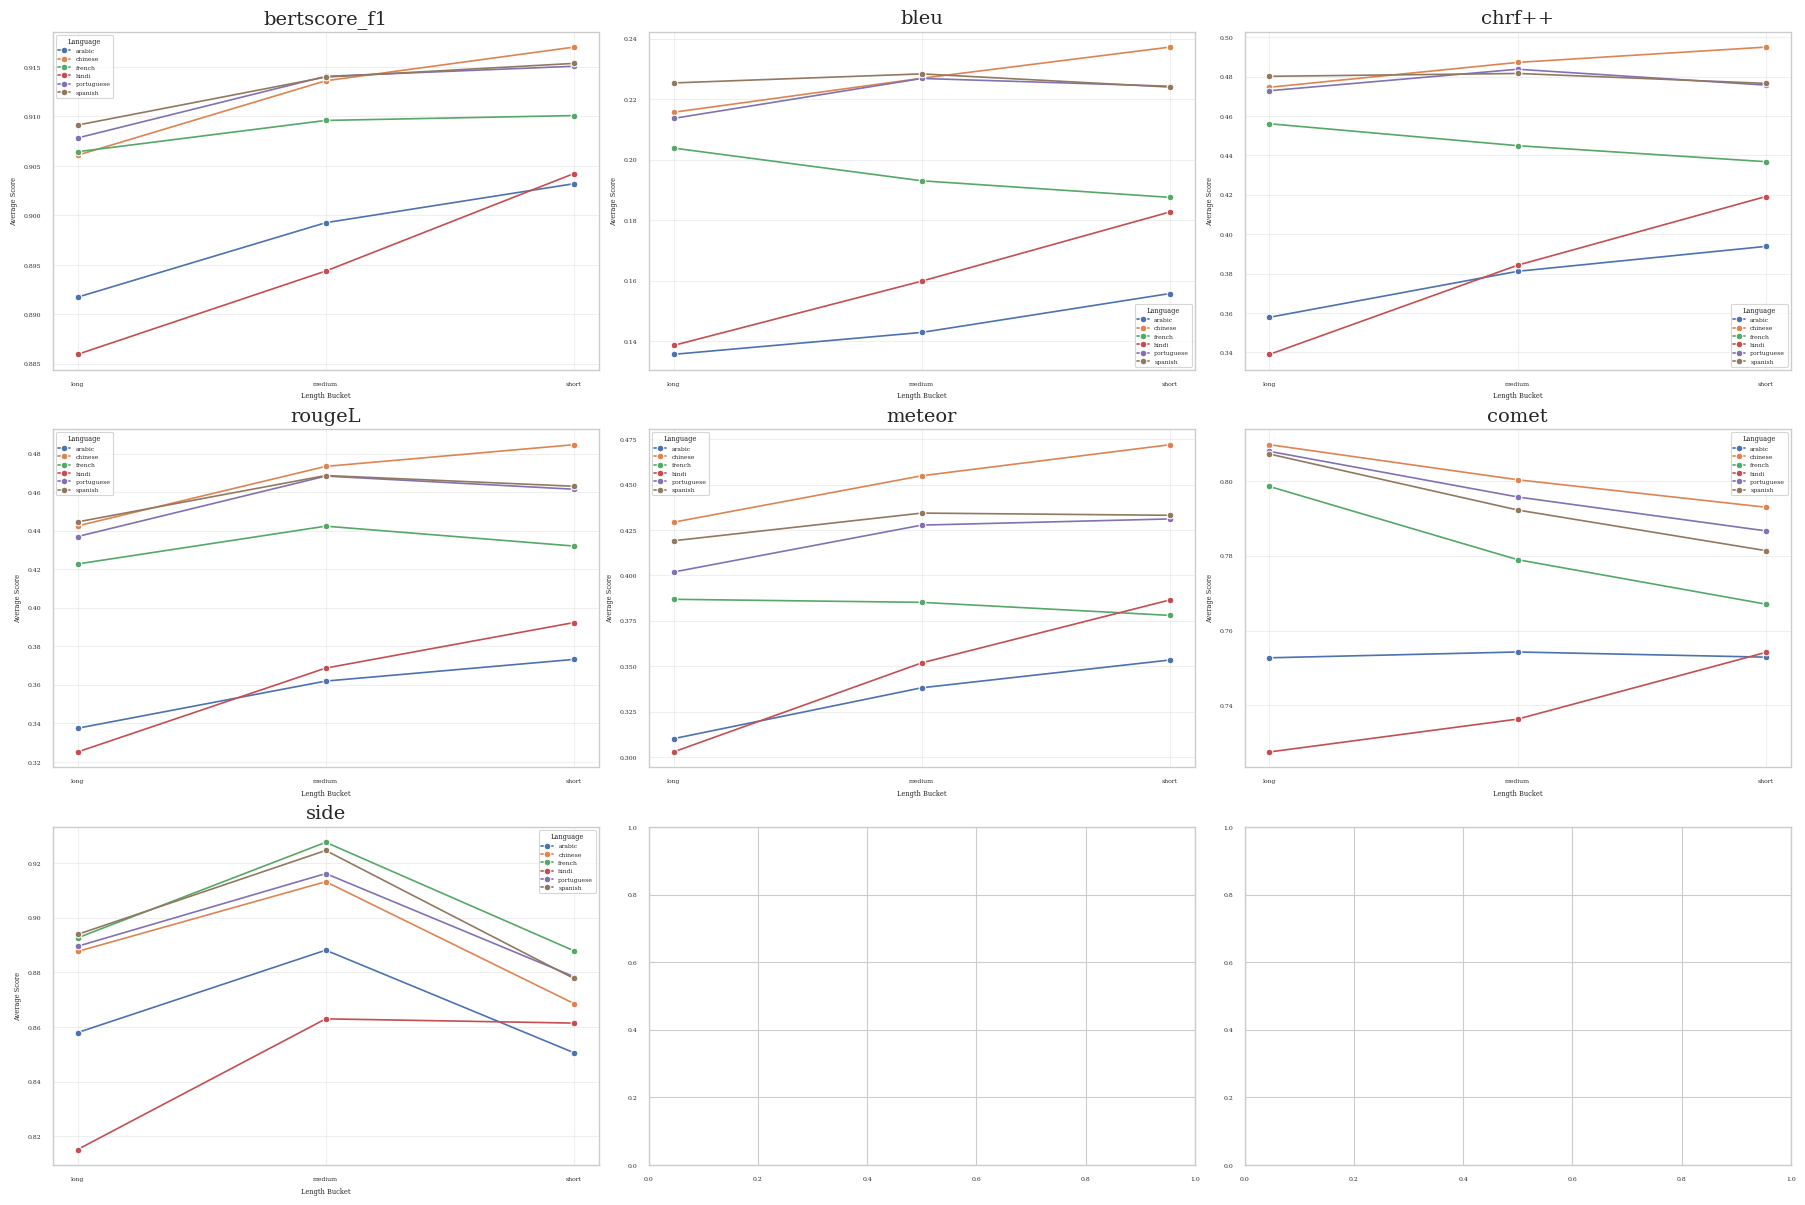

In [11]:


fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 12))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    sns.lineplot(
        data=avg_scores,
        x='length_bucket',
        y=metric,
        hue='bt_language',
        marker='o',
        ax=axes[i]
    )
    axes[i].set_title(metric, fontsize=14)
    axes[i].legend(title='Language')
    axes[i].set_xlabel('Length Bucket')
    axes[i].set_ylabel('Average Score')
    axes[i].grid(True, alpha=0.3)


plt.tight_layout()
filename = os.path.join(figures_dir, "nlxpl_buckets.png")
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()


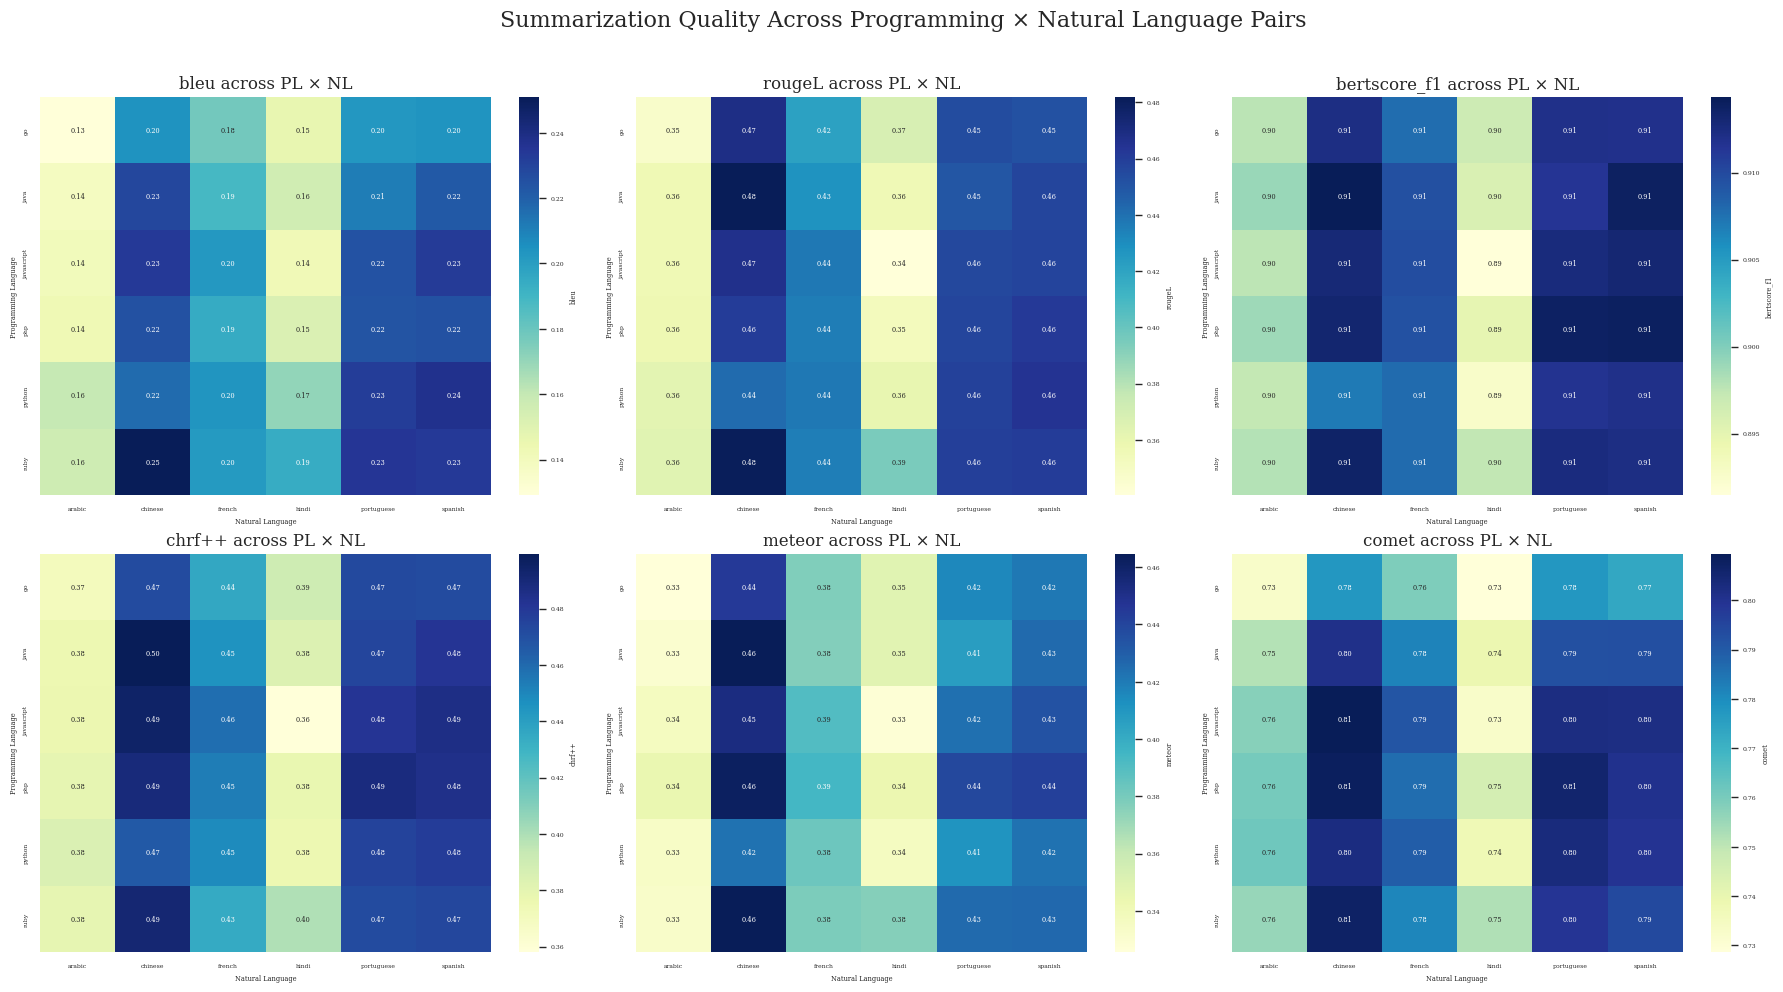

In [12]:
metrics = ["bleu", "rougeL", "bertscore_f1", "chrf++", "meteor", "comet"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    pivot = df.groupby(["programming_language", "bt_language"])[metric].mean().reset_index()
    pivot_table = pivot.pivot(index='programming_language', columns='bt_language', values=metric)

    sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap="YlGnBu", ax=axes[i], cbar_kws={'label': metric})
    axes[i].set_title(f"{metric} across PL × NL", fontsize=12)
    axes[i].set_xlabel("Natural Language")
    axes[i].set_ylabel("Programming Language")

plt.suptitle("Summarization Quality Across Programming × Natural Language Pairs", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
filename = os.path.join(figures_dir, "nlvspl.png")
plt.savefig(filename, dpi=400, bbox_inches='tight')
plt.show()

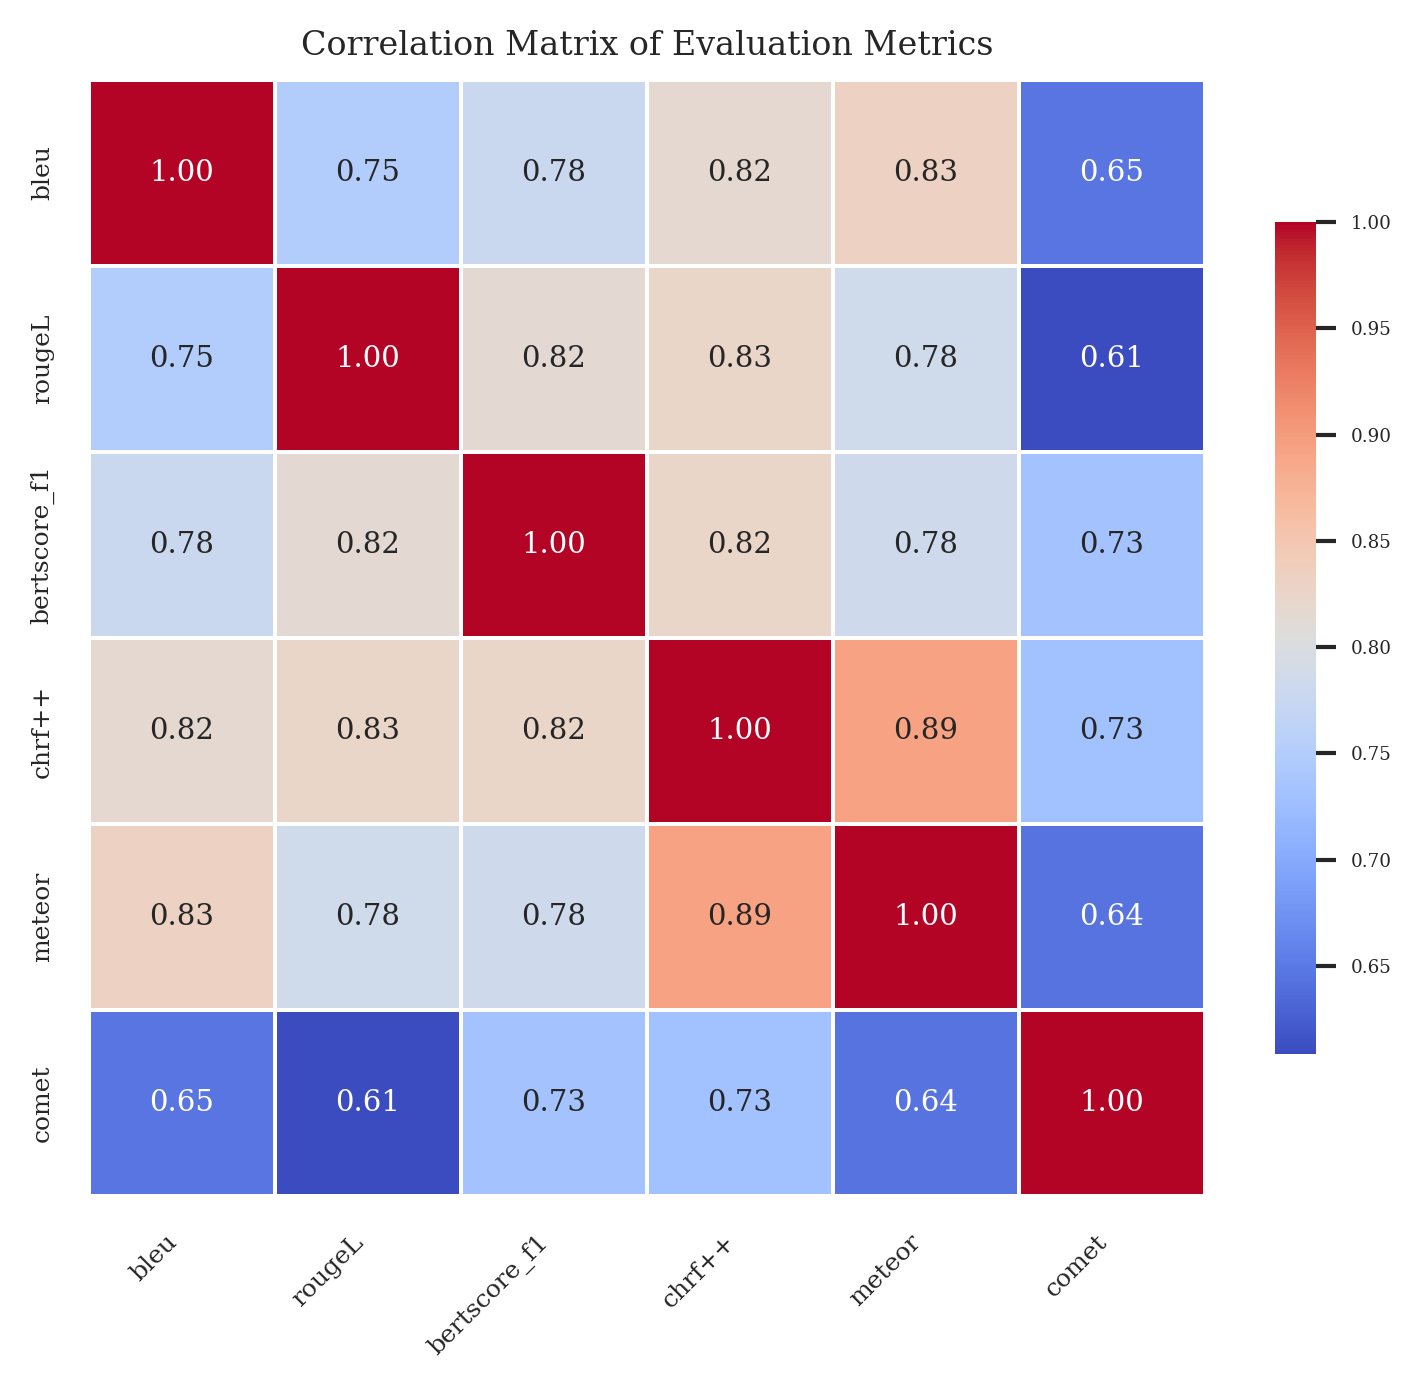

In [13]:
corr = df[metrics].corr()

plt.figure(figsize=(6, 6), dpi=300)
heatmap = sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.6},
    annot_kws={"size": 7}
)

# --- Title and Layout ---
plt.title('Correlation Matrix of Evaluation Metrics', fontsize=8)
plt.xticks(rotation=45, ha='right', fontsize=6)
plt.yticks(fontsize=6)
# --- Save ---
filename = os.path.join(figures_dir,"corr_eval_metrics.png")
plt.savefig(filename, dpi=400, bbox_inches='tight')


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

# --- Compute correlation ---
corr = df[metrics].corr()

# --- Pretty labels ---
name_map = {
    'bleu': 'BLEU',
    'rougeL': 'ROUGE-L',
    'bertscore_f1': 'BERTScore (F1)',   # add (F1)
    'chrf++': 'ChrF++',
    'meteor': 'METEOR',
    'comet': 'COMET',
    'side': 'SIDE',
}
labels = [name_map.get(col, col) for col in corr.columns]

# --- Global style (bold serif textsc-like) ---
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # or "Times"
})

plt.figure(figsize=(6, 6), dpi=300)
ax = sns.heatmap(
    corr,
    annot=True, fmt=".2f",
    cmap='coolwarm',
    square=True, linewidths=0.5,
    cbar_kws={"shrink": 0.6},
    annot_kws={"size": 8, "weight": "bold"},
    xticklabels=labels,
    yticklabels=labels
)

# --- Styling: bold tilted labels, no tick marks/arrows ---
ax.set_title("PEARSON CORRELATION MATRIX OF EVALUATION METRICS", fontsize=10, weight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8, weight='bold')
ax.set_yticklabels(ax.get_yticklabels(), rotation=45, va='center', fontsize=8, weight='bold')

# remove the small arrows / ticks
ax.tick_params(
    axis='both',
    which='both',
    length=0,    # removes tick marks
    width=0,     # removes tick lines
    labelbottom=True,
    labelleft=True
)

plt.tight_layout()

# --- Save ---
filename = os.path.join(figures_dir,"corr_eval_metrics_pearson.png")
plt.savefig(filename, dpi=400, bbox_inches="tight")
plt.close()


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

# --- Compute Spearman correlation ---
corr_spearman = df[metrics].corr(method='spearman')

# --- Pretty labels ---
name_map = {
    'bleu': 'BLEU',
    'rougeL': 'ROUGE-L',
    'bertscore_f1': 'BERTScore (F1)',
    'chrf++': 'ChrF++',
    'meteor': 'METEOR',
    'comet': 'COMET',
    'side': 'SIDE',
}
labels = [name_map.get(col, col) for col in corr_spearman.columns]

# --- Global style (bold serif textsc-like) ---
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # or "Times"
})

plt.figure(figsize=(6, 6), dpi=300)
ax = sns.heatmap(
    corr_spearman,
    annot=True, fmt=".2f",
    cmap='coolwarm',
    square=True, linewidths=0.5,
    cbar_kws={"shrink": 0.6},
    annot_kws={"size": 8, "weight": "bold"},
    xticklabels=labels,
    yticklabels=labels
)

# --- Styling: bold tilted labels, no tick marks/arrows ---
ax.set_title("SPEARMAN CORRELATION MATRIX OF EVALUATION METRICS",
             fontsize=10, weight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8, weight='bold')
ax.set_yticklabels(ax.get_yticklabels(), rotation=45, va='center', fontsize=8, weight='bold')

# remove the small arrows / ticks
ax.tick_params(
    axis='both',
    which='both',
    length=0,
    width=0,
    labelbottom=True,
    labelleft=True
)

plt.tight_layout()

# --- Save ---
filename = os.path.join(figures_dir,"corr_eval_metrics_spearman.png")
plt.savefig(filename, dpi=400, bbox_inches='tight')
plt.close()


In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pearson_corr = df[metrics].corr(method='pearson')
spearman_corr = df[metrics].corr(method='spearman')

# mask upper / lower triangles
mask_upper = np.triu(np.ones_like(pearson_corr, dtype=bool))
mask_lower = np.tril(np.ones_like(spearman_corr, dtype=bool))

fig, ax = plt.subplots(figsize=(6, 6), dpi=300)

sns.heatmap(
    pearson_corr,
    mask=mask_lower,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    annot_kws={"size": 7, "weight": "bold"},
    cbar=False,
    ax=ax
)

sns.heatmap(
    spearman_corr,
    mask=mask_upper,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    annot_kws={"size": 7},
    cbar_kws={"shrink": 0.6},
    ax=ax
)

ax.set_title("Metric Correlations (Pearson upper / Spearman lower)", fontsize=9, weight="bold")
ax.set_xticklabels(ax.get_xticklabels(), fontsize=7, weight="bold", rotation=45, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), fontsize=7, weight="bold")
plt.tight_layout()
filename = os.path.join(figures_dir,"corr_eval_metrics_combined.png")
plt.savefig(filename, dpi=400, bbox_inches="tight")
plt.close()



In [17]:


avg_scores = df.groupby('model_name')[metrics].mean().reset_index()

avg_melted = avg_scores.melt(
    id_vars='model_name',
    value_vars=metrics,
    var_name='Metric',
    value_name='Score'
)

avg_melted['Metric'] = avg_melted['Metric'].map(metric_labels)


plt.figure(figsize=(10, 6), dpi=400)
ax = sns.barplot(
    data=avg_melted,
    x='Metric',
    y='Score',
    hue='model_name',
    palette='Set2',
    edgecolor='black'
)

for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height) and height > 0:
        if height >= 1:
            label = f"{height:.1f}"
        elif height >= 0.1:
            label = f"{height:.2f}"
        else:
            label = f"{height:.3f}"
        ax.annotate(label,
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=6, color='black')

# --- Labels and Legend ---
ax.set_title('Average Metric Scores per Model', fontsize=9)
ax.set_ylabel('Average Score', fontsize=7)
ax.set_xlabel('Evaluation Metric', fontsize=7)
ax.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6, title_fontsize=6)

plt.xticks(fontsize=7)
plt.yticks(fontsize=7)

# --- Save ---
filename = os.path.join(figures_dir, "avg_metric_per_model.png")
plt.savefig(filename, dpi=400, bbox_inches="tight")
plt.close()

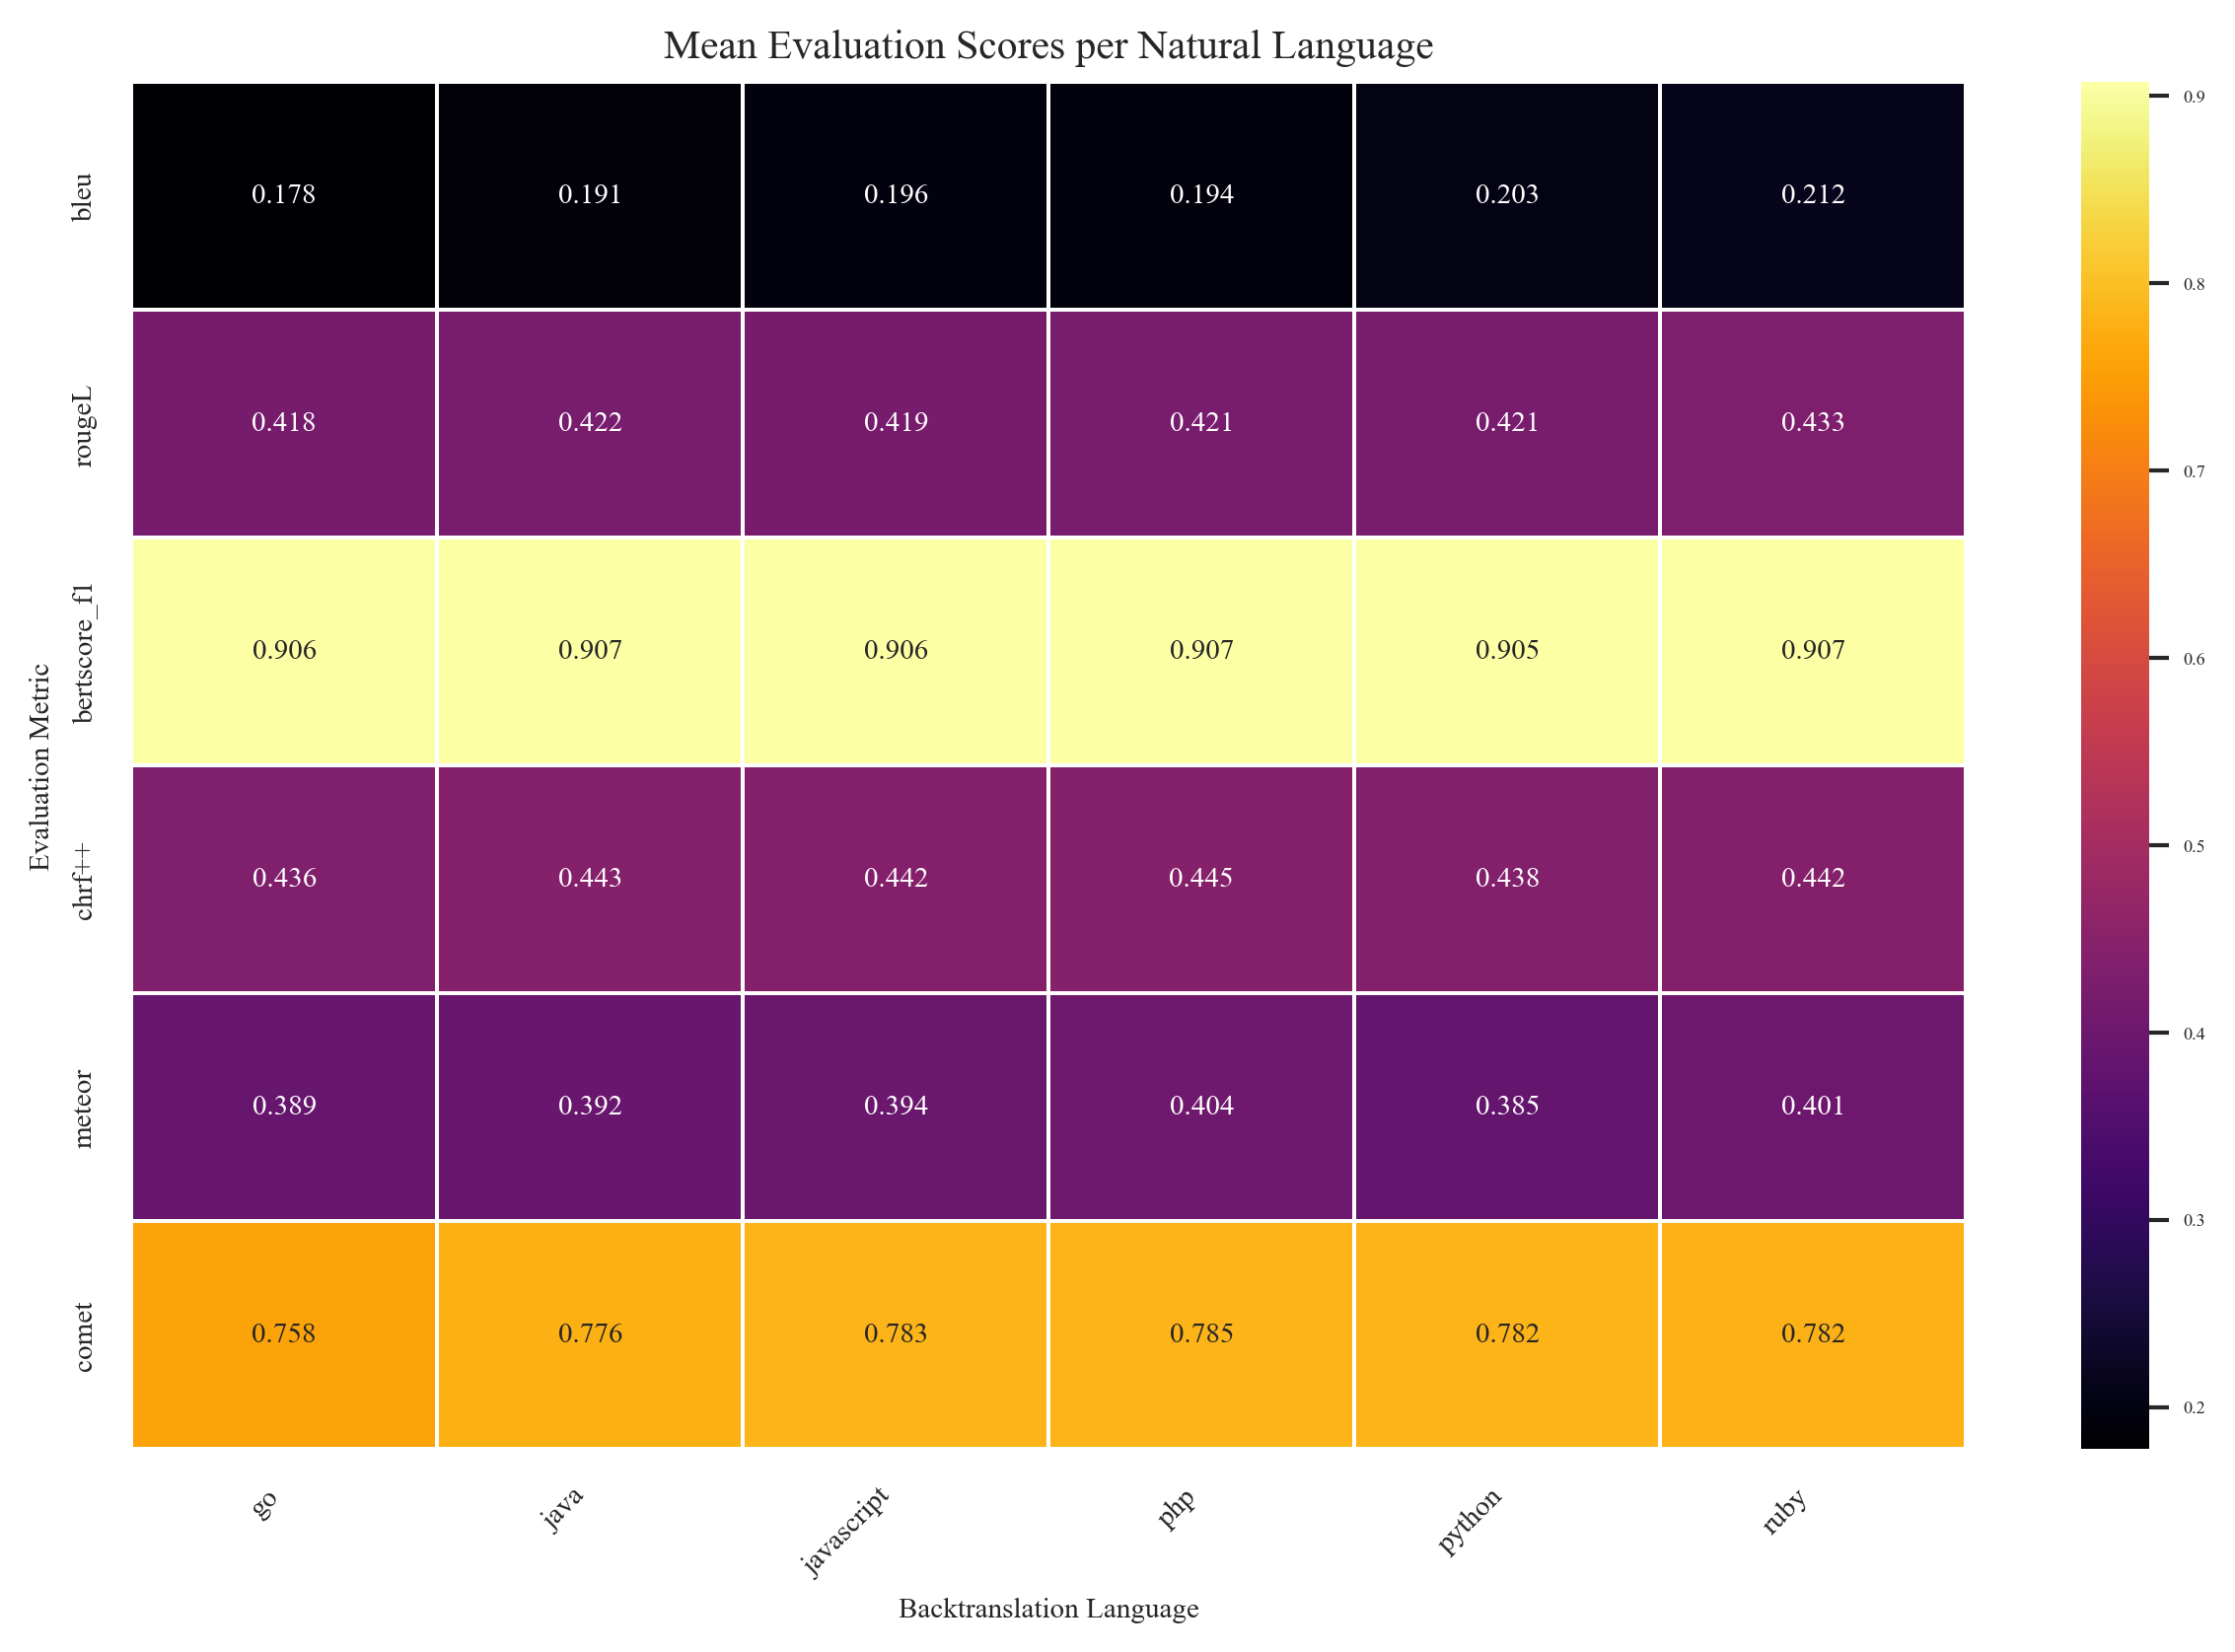

In [18]:

lang_metric_map = df.groupby('programming_language')[metrics].mean().T

# --- Plot ---
plt.figure(figsize=(10, 6), dpi=300)
sns.heatmap(
    lang_metric_map,
    annot=True,
    fmt=".3f",
    cmap='inferno',
    linewidths=0.5,
    annot_kws={"size": 7}
)

plt.title('Mean Evaluation Scores per Natural Language', fontsize=10)
plt.xlabel('Backtranslation Language', fontsize=7)
plt.ylabel('Evaluation Metric', fontsize=7)
plt.xticks(fontsize=7, rotation=45, ha='right')
plt.yticks(fontsize=7)
filename = os.path.join(figures_dir, "mean_eval_per_nl.png")
plt.savefig(filename, dpi=400, bbox_inches='tight')


In [19]:
# --- Melt into long format ---
df_melted = df.melt(
    id_vars=['bt_language'],
    value_vars=metrics,
    var_name='Metric',
    value_name='Score'
)

# Map to readable metric names
df_melted['Metric'] = df_melted['Metric'].map(metric_labels)

# --- Compute averages ---
avg_scores = df_melted.groupby(['bt_language', 'Metric'], as_index=False)['Score'].mean()

# --- Convert to percentages ---
avg_scores['Score'] *= 100

# --- Plot ---
plt.figure(figsize=(8, 6), dpi=300)
custom_palette = sns.color_palette("Set2")

ax = sns.barplot(
    data=avg_scores,
    x='bt_language',
    y='Score',
    hue='Metric',
    palette=custom_palette,
    edgecolor='black'
)

# --- Axis Labels and Title ---
ax.set_title("Average Metric Scores by Language", fontsize=9)
ax.set_xlabel("Natural Language", fontsize=9)
ax.set_ylabel("Mean Score", fontsize=9)

# --- Legend ---
ax.legend(title='Evaluation Metric', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

# --- Save ---
filename = os.path.join(figures_dir, "avg_metric_by_language.png")
plt.savefig(filename, dpi=400, bbox_inches="tight")
plt.close()

/var/folders/73/zlm0snx17w7_6tq_p4897nnw0000gn/T/ipykernel_16886/2954551682.py:22: UserWarning: The palette list has more values (8) than needed (6), which may not be intended.
  ax = sns.barplot(


In [20]:

metrics = [
    ("bleu", "BLEU"),
    ("bertscore_f1", "BERTScore"),
    ("rougeL", "ROUGE-L"),
    ("meteor", "METEOR"),
    ("chrf++", "chrF++"),
    ("comet", "COMET")
]

fig, axs = plt.subplots(2, 3, figsize=(16, 9), dpi=150)
axs = axs.flatten()
for ax, (metric_col, metric_name) in zip(axs, metrics):
    sns.scatterplot(
        data=df,
        x=metric_col,
        y="side",
        hue="bt_language",
        ax=ax,
        palette="Set2"
    )
    ax.set_title(metric_name, fontsize=12)
    ax.set_xlabel("Metric Score", fontsize=10)
    ax.set_ylabel("SIDE (BT)", fontsize=10)
    ax.tick_params(labelsize=8)
    legend = ax.get_legend()
    if legend:
        legend.remove()  # remove individual legends

handles, labels = axs[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title='Language',
    title_fontsize=10,
    fontsize=9,
    loc='center right',
    bbox_to_anchor=(1.05, 0.5),
    borderaxespad=1.0
)

fig.text(0.5, 1.02, "SIDE vs Other Metrics Across Languages", ha='center', fontsize=14)
plt.tight_layout(rect=[0, 0, 0.95, 0.98])
filename = os.path.join(figures_dir,"side_vs_metrics.png")
plt.savefig(filename, dpi=400, bbox_inches='tight')
plt.close()

In [21]:

# --- Helper functions for lengths ---
def n_chars(s): return len(str(s)) if pd.notna(s) else np.nan
def n_words(s): return len(str(s).split()) if pd.notna(s) else np.nan
def n_lines(s): return str(s).count("\n")+1 if pd.notna(s) else np.nan

# --- Compute complexity features ---
df["code_chars"] = df["code"].apply(n_chars)
df["code_words"] = df["code"].apply(n_words)
df["code_lines"] = df["code"].apply(n_lines)

df["ref_chars"] = df["reference_summary"].apply(n_chars)
df["ref_words"] = df["reference_summary"].apply(n_words)
df["ref_lines"] = df["reference_summary"].apply(n_lines)

# --- Metrics you already track ---
metrics = ['bertscore_precision','bertscore_recall','bertscore_f1',
           'bleu','chrf++','rougeL','meteor','comet','side']

# --- Aggregate: avg code size + avg scores per bucket ---
group_keys = ["programming_language","bt_language","length_bucket"]

size_stats = (
    df.groupby(group_keys, observed=False)[
        ["code_chars","code_words","code_lines","ref_chars","ref_words","ref_lines"]
    ]
    .agg(["mean","std","median","min","max"])
)

# Flatten column names
size_stats.columns = ["_".join([c for c in col if c]) for col in size_stats.columns.to_flat_index()]
size_stats = size_stats.reset_index()

# Aggregate metric averages per bucket
metric_means = (
    df.groupby(group_keys, observed=False)[metrics].mean().reset_index()
)

# Merge together
consolidated = size_stats.merge(metric_means, on=group_keys, how="left")

# Save for later analysis
consolidated.to_csv("/Users/madhurimachakraborty/Documents/GitHub/CodeClarity/data/complexity_bucket_stats_and_scores.csv", index=False)

print("Saved bucket stats with complexity + scores to data/complexity_bucket_stats_and_scores.csv")

Saved bucket stats with complexity + scores to data/complexity_bucket_stats_and_scores.csv


In [22]:
df = pd.read_csv("/Users/madhurimachakraborty/Documents/GitHub/CodeClarity/data/evalScores0.7.csv")
df.head()

,sample_id,model_name,programming_language,length_bucket,bt_language,reference_summary,generated_summary,backtranslated_summary,bertscore_precision,bertscore_recall,bertscore_f1,bleu,chrf++,rougeL,meteor,comet,side,prompt_used,code,docstring
0,sample_68262,codegemma-7b-it,go,short,chinese,## Code Summary:\n\n**Function:** Use\n\n**Pur...,**函数名称：** Use\n\n**函数用途：** 将给定的路由处理器添加到 Handle...,**Function Name:** Use\n\n**Function Purpose:*...,0.9173,0.913,0.9151,0.328843,0.479059,0.377358,0.525757,0.793025,0.951876,0,func (hs *HandlersStack) Use(h RouterHandler) ...,// Use adds a handler to the handlers stack.
1,sample_68262,codegemma-7b-it,go,short,chinese,## Code Summary:\n\n**Function:** Use\n\n**Pur...,**函数名称：** Use\n\n**函数用途：** 将给定的路由处理器添加到 Handle...,**Function Name:** Use\n\n**Function Purpose:*...,0.9173,0.913,0.9151,0.328843,0.479059,0.377358,0.525757,0.793025,0.951876,0,func (hs *HandlersStack) Use(h RouterHandler) ...,// Use adds a handler to the handlers stack.
2,sample_68262,codegemma-7b-it,go,short,chinese,## Code Summary:\n\n**Function:** Use\n\n**Pur...,**函数名称：** Use\n\n**函数用途：** 将给定的路由处理器添加到 Handle...,**Function Name:** Use\n\n**Function Purpose:*...,0.9173,0.913,0.9151,0.328843,0.479059,0.377358,0.525757,0.793025,0.951876,0,func (hs *HandlersStack) Use(h RouterHandler) ...,// Use adds a handler to the handlers stack.
3,sample_68262,codegemma-7b-it,go,short,chinese,## Code Summary:\n\n**Function:** Use\n\n**Pur...,**函数名称：** Use\n\n**函数用途：** 将给定的路由处理器添加到 Handle...,**Function Name:** Use\n\n**Function Purpose:*...,0.9173,0.913,0.9151,0.328843,0.479059,0.377358,0.525757,0.793025,0.951876,0,func (hs *HandlersStack) Use(h RouterHandler) ...,// Use adds a handler to the handlers stack.
4,sample_68262,codegemma-7b-it,go,short,chinese,## Code Summary:\n\n**Function:** Use\n\n**Pur...,**函数名称：** Use\n\n**函数用途：** 将给定的路由处理器添加到 Handle...,**Function Name:** Use\n\n**Function Purpose:*...,0.9173,0.913,0.9151,0.328843,0.479059,0.377358,0.525757,0.793025,0.951876,0,func (hs *HandlersStack) Use(h RouterHandler) ...,// Use adds a handler to the handlers stack.


In [23]:
# Collapse to unique code samples first (1 row per sample_id × programming_language)
unique_samples = (
    df.drop_duplicates(subset=["sample_id", "programming_language"])
      .loc[:, ["sample_id", "programming_language", "length_bucket", "bt_language", "code"]]
)

# Add code length features
unique_samples["code_len_tokens"] = unique_samples["code"].fillna("").str.split().str.len()
unique_samples["code_len_lines"]  = unique_samples["code"].fillna("").str.count("\n") + 1
unique_samples["code_len_chars"]  = unique_samples["code"].fillna("").str.len()

# Now compute bucket-level stats (these won’t be inflated by 24× repeats)
bucket_code_stats = (
    unique_samples.groupby(["programming_language", "length_bucket"], as_index=False)
    .agg(
        n_samples=("sample_id", "nunique"),
        avg_code_len_tokens=("code_len_tokens", "mean"),
        median_code_len_tokens=("code_len_tokens", "median"),
        std_code_len_tokens=("code_len_tokens", "std"),
        min_code_len=("code_len_tokens", "min"),
        max_code_len=("code_len_tokens", "max")
    )
)
import matplotlib.pyplot as plt
import os

# Example: plot average token length by language and length bucket
plt.figure(figsize=(10, 6))
for lang, grp in bucket_code_stats.groupby("programming_language"):
    plt.plot(grp["length_bucket"], grp["avg_code_len_tokens"], marker='o', label=lang)

plt.xlabel("Length Bucket")
plt.ylabel("Average Code Length (tokens)")
plt.title("Average Code Length by Language and Bucket")
plt.legend()
plt.tight_layout()

# Save as PNG
filename = os.path.join(figures_dir,"bucket_code_stats.png")
plt.savefig(filename, dpi=300)
plt.close()


In [24]:
import numpy as np

def degradation_rate(df, score_col="bleu"):
    # sort buckets logically (short < medium < long)
    mapping = {"short": 1, "medium": 2, "long": 3}
    df = df.assign(bucket_num=df["length_bucket"].map(mapping))
    # linear regression slope
    coeffs = np.polyfit(df["bucket_num"], df[score_col], 1)
    return coeffs[0]  # slope (negative = decline)

rates = (
    df.groupby(["bt_language"])[["length_bucket", "bleu"]]
      .apply(degradation_rate)
      .reset_index(name="bleu_slope")
)


In [25]:
metrics = ["bleu", "rougeL", "chrf++", "meteor", "comet", "side"]
all_slopes = []

for metric in metrics:
    tmp = (
        df.groupby(["bt_language"])[["length_bucket", metric]]
          .apply(degradation_rate, score_col=metric)
          .reset_index(name=f"{metric}_slope")
    )
    all_slopes.append(tmp)

# Merge all slopes into one DataFrame
from functools import reduce
slopes_df = reduce(lambda left, right: pd.merge(left, right, on="bt_language"), all_slopes)
slopes_df.to_csv("/Users/madhurimachakraborty/Documents/GitHub/CodeClarity/figures/all_metric_degradation_slopes.csv", index=False)


In [26]:
slopes_df_melted = slopes_df.melt(id_vars="bt_language", var_name="metric", value_name="slope")

plt.figure(figsize=(8, 4))
sns.barplot(data=slopes_df_melted, x="bt_language", y="slope", hue="metric")
plt.axhline(0, color="black", lw=0.8)
plt.title("Metric degradation slopes by language (short → long)")
plt.ylabel("Slope (Δ per length bucket)")
plt.xlabel("Language")
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
filename = os.path.join(figures_dir, "metric_degradation_slopes_by_language.png")
plt.savefig(filename, dpi=400, bbox_inches="tight")
plt.close()


In [27]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')
table = ax.table(cellText=bucket_code_stats.values,
                 colLabels=bucket_code_stats.columns,
                 loc='center')
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.2, 1.2)

filename = os.path.join(figures_dir,"bucket_code_stats.png")
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.close()


In [28]:
df['has_code'] = df['code'].notna()
df.groupby('programming_language')['has_code'].mean().sort_values()


programming_language
go            1.0
java          1.0
javascript    1.0
php           1.0
python        1.0
ruby          1.0
Name: has_code, dtype: float64

In [29]:
metrics = ["bleu", "rougeL", "bertscore_f1", "chrf++", "meteor", "comet", "side"]

bucket_summary = (
    df.groupby("length_bucket")[metrics]
      .mean()
      .reset_index()
      .round(3)
)
bucket_summary


,length_bucket,bleu,rougeL,bertscore_f1,chrf++,meteor,comet,side
0,long,0.189,0.403,0.901,0.431,0.376,0.784,0.873
1,medium,0.197,0.432,0.908,0.445,0.399,0.777,0.906
2,short,0.202,0.435,0.911,0.450,0.409,0.773,0.871


In [30]:
import pandas as pd
import numpy as np
from pathlib import Path
import dataframe_image as dfi

# ---- 1) Compute bucket means across all PL × NL × models ----
metrics = ["bleu","rougeL","bertscore_f1","chrf++","meteor","comet","side"]
tbl = (
    df.groupby("length_bucket", as_index=False)[metrics]
      .mean()
      .pipe(lambda _df: _df.assign(length_bucket=pd.Categorical(
          _df["length_bucket"],
          # reorder if you use these names; else it will keep your existing order
          categories=["short","medium","long"],
          ordered=True)))
      .sort_values("length_bucket")
      .set_index("length_bucket")
      .round(3)
)

# Optional: nicer column labels
tbl = tbl.rename(columns={
    "bertscore_f1":"BERTScore (F1)",
    "rougeL":"ROUGE-L",
    "chrf++":"ChrF++",
    "meteor":"METEOR",
    "bleu":"BLEU",
    "comet":"COMET",
    "side":"SIDE",
})

# ---- 2) Style for notebook display ----
sty = (tbl.style
       .format("{:.3f}")
       .set_caption("Reference-based Metrics: Average Scores by Code-Length Bucket")
       .background_gradient(axis=0, cmap="YlGnBu")   # pretty heatmap-style background
       .set_table_styles([
           {"selector":"caption","props":[("caption-side","top"),("font-weight","bold")]},
           {"selector":"th","props":[("text-align","center")]},
           {"selector":"td","props":[("text-align","center")]}
       ])
)

display(sty)

dfi.export(sty, "/Users/madhurimachakraborty/Documents/GitHub/CodeClarity/figures/bucket_summary.png", table_conversion="matplotlib", dpi=300)

# ---- 3) Save nice artifacts ----
outdir = Path("/Users/madhurimachakraborty/Documents/GitHub/CodeClarity/figures"); outdir.mkdir(parents=True, exist_ok=True)
tbl.to_csv(outdir/"bucket_summary.csv")
with open(outdir/"bucket_summary.tex","w") as f:
    f.write(tbl.to_latex(escape=False, bold_rows=False, column_format="lrrrrrrr"))
sty.to_html(outdir/"bucket_summary.html")  # shareable pretty HTML
print("Saved:", outdir/"bucket_summary.csv", outdir/"bucket_summary.tex", outdir/"bucket_summary.html")


,BLEU,ROUGE-L,BERTScore (F1),ChrF++,METEOR,COMET,SIDE
length_bucket,,,,,,,
short,0.202,0.435,0.911,0.450,0.409,0.773,0.871
medium,0.197,0.432,0.908,0.445,0.399,0.777,0.906
long,0.189,0.403,0.901,0.431,0.376,0.784,0.873


Saved: /Users/madhurimachakraborty/Documents/GitHub/CodeClarity/figures/bucket_summary.csv /Users/madhurimachakraborty/Documents/GitHub/CodeClarity/figures/bucket_summary.tex /Users/madhurimachakraborty/Documents/GitHub/CodeClarity/figures/bucket_summary.html


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8.2, 2.8), dpi=300)
ax = sns.heatmap(tbl.values, annot=True, fmt=".3f",
                 cmap="YlGnBu", vmin=0.0, vmax=1.0,  # common scale
                 cbar_kws={"label":"Score (0–1)"}, linewidths=0.5)

ax.set_yticklabels([r.capitalize() for r in tbl.index], rotation=0, weight="bold")
ax.set_xticklabels(tbl.columns, rotation=30, ha="right", weight="bold")
plt.title("Reference-based Metrics: Average Scores by Code-Length Bucket", weight="bold")
plt.tight_layout()
filename = os.path.join(figures_dir,"bucket_summary.png")
plt.savefig(filename,
            dpi=400, bbox_inches="tight")
plt.close()
